In [1]:
!hostname

chinook04.rcs.alaska.edu


In [2]:
import xarray as xr
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import HTML
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm


ros_colorbar = LinearSegmentedColormap.from_list('ros', [ 
    '#4B2D1A',  # deep brown
    '#7A4A22',  # warm brown
    '#B5743C',  # lighter brown
    '#E3C7A3',  # tan
    #'#F7F7F7',  # near-white (neutral midpoint!)
    '#CFE8F3',  # very light blue
    '#9ECAE1',  # soft blue
    '#5DA5DA',  # medium blue
    '#2B7BBA',  # deeper blue
    '#1B4F72'   # muted dark blue
    ])


brbg_white = LinearSegmentedColormap.from_list(
    'brbg_white',
    [
        '#543005','#8c510a','#bf812d','#dfc27d','#f6e8c3',
        '#ffffff',
        '#c7eae5','#80cdc1','#35978f','#01665e','#003c30'
    ],
    N=256)


snowpack_cmap = LinearSegmentedColormap.from_list('snowpack', [
    '#4B2D1A',  # deep dry soil brown
    '#7A4A22',  # warm brown
    '#C08A4B',  # dry tan
    '#E6D2B5',  # pale dry snow/soil
    '#F7F7F7',  # near-white midpoint
    '#E0E0E0',  # light gray (slightly wet shift)
    '#B8B8C8',  # cool gray-lavender (wet direction starts)
    '#8E8EA8',  # muted slate purple-gray
    '#5E5E78',  # deep muted cool gray
    '#2F2F3A'   # very dark neutral wet extreme
], N=256)

swe_colorbar= brbg_white
rain_colorbar = brbg_white


import cmocean
cmocean_options=cmocean.cm.cmap_d;
oceanrain=cmocean_options['rain']

In [3]:
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files'
monthly=xr.open_dataset(path+'/theilsen_trend_mannkndall_monthly_1950_2022.nc')
monthly

<xarray.Dataset> Size: 1GB
Dimensions:                                  (month: 5, south_north: 450,
                                              west_east: 420, interp_level: 3)
Coordinates:
  * month                                    (month) int64 40B 11 12 1 2 3
    XLAT                                     (south_north, west_east) float32 756kB ...
    XLONG                                    (south_north, west_east) float32 756kB ...
    month_name                               (month) <U3 60B ...
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/104)
    ros_tally_slope_theilsen                 (month, south_north, west_east) float64 8MB ...
    ros_tally_intercept_theilsen             (month, south_north, west_east) float64 8MB ...
    ros_tally_low_slope_theilsen             (month, south_north, west_east) float64 8MB ...
    ros_tally_high_slope_theilsen            (month, south_north, west_east) float64 8MB ...
    ros_counts_slope_theilsen                (month, south_north, west_east) float64 8MB ...
    ros_counts_intercept_theilsen            (month, south_north, west_east) float64 8MB ...
    ...                                       ...
    temp_levels_avg_S_mannkendall            (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_avg_var_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_tau_mannkendall      (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_p_value_mannkendall  (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_var_S_mannkendall    (month, interp_level, south_north, west_east) float64 23MB ...

In [4]:
seasonal=xr.open_dataset(path+'/theilsen_trend_mannkndall_seasonal_1950_2022.nc')
seasonal

<xarray.Dataset> Size: 207MB
Dimensions:                                  (south_north: 450, west_east: 420,
                                              interp_level: 3)
Coordinates:
    XLAT                                     (south_north, west_east) float32 756kB ...
    XLONG                                    (south_north, west_east) float32 756kB ...
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/104)
    ros_tally_slope_theilsen                 (south_north, west_east) float64 2MB ...
    ros_tally_intercept_theilsen             (south_north, west_east) float64 2MB ...
    ros_tally_low_slope_theilsen             (south_north, west_east) float64 2MB ...
    ros_tally_high_slope_theilsen            (south_north, west_east) float64 2MB ...
    ros_counts_slope_theilsen                (south_north, west_east) float64 2MB ...
    ros_counts_intercept_theilsen            (south_north, west_east) float64 2MB ...
    ...                                       ...
    temp_levels_avg_S_mannkendall            (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_avg_var_S_mannkendall        (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_tau_mannkendall      (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_p_value_mannkendall  (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_S_mannkendall        (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_var_S_mannkendall    (interp_level, south_north, west_east) float64 5MB ...

In [5]:
def plot_row(ax_row, datasets):
    for ax, (data, pvals, title) in zip(ax_row, datasets):
        pcm = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            shading='auto',
            transform=ccrs.PlateCarree()
        )

        sig = pvals < 0.05

        ax.contourf(
            lon, lat, sig,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'],
            transform=ccrs.PlateCarree()
        )

        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.add_feature(cfeature.BORDERS, zorder=8)
        ax.add_feature(cfeature.COASTLINE, zorder=8)
        ax.add_feature(cfeature.RIVERS, zorder=8)
        ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
        ax.set_aspect('equal')

    return pcm

In [6]:
'''
lat = data['XLAT'].isel(west_east=0).values
lon = data['XLONG'].isel(south_north=0).values
'''

"\nlat = data['XLAT'].isel(west_east=0).values\nlon = data['XLONG'].isel(south_north=0).values\n"

In [7]:
'''
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files'

rain_ros_avg = xr.open_dataset(path+'/linear_trend_rain_ros_avg_1950_2022.nc')
rain_ros_sum = xr.open_dataset(path+'/linear_trend_rain_ros_sum_1950_2022.nc')
ros_days_count = xr.open_dataset(path+'/linear_trend_ros_days_count_1950_2022.nc')
ros_tally = xr.open_dataset(path+'/linear_trend_ros_tally_1950_2022.nc')
T2_avg = xr.open_dataset(path+'/linear_trend_T2_avg_1950_2022.nc')
T2_ros_avg = xr.open_dataset(path+'/linear_trend_T2_ros_avg_1950_2022.nc')  
swe_avg=xr.open_dataset(path+'/linear_trend_swe_avg_1950_2022.nc') 
seasonal_ros_hourly = xr.open_dataset(path+'/linear_seasonal_trend_ros_hourly_1950_2022.nc')
'''

"\npath='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files'\n\nrain_ros_avg = xr.open_dataset(path+'/linear_trend_rain_ros_avg_1950_2022.nc')\nrain_ros_sum = xr.open_dataset(path+'/linear_trend_rain_ros_sum_1950_2022.nc')\nros_days_count = xr.open_dataset(path+'/linear_trend_ros_days_count_1950_2022.nc')\nros_tally = xr.open_dataset(path+'/linear_trend_ros_tally_1950_2022.nc')\nT2_avg = xr.open_dataset(path+'/linear_trend_T2_avg_1950_2022.nc')\nT2_ros_avg = xr.open_dataset(path+'/linear_trend_T2_ros_avg_1950_2022.nc')  \nswe_avg=xr.open_dataset(path+'/linear_trend_swe_avg_1950_2022.nc') \nseasonal_ros_hourly = xr.open_dataset(path+'/linear_seasonal_trend_ros_hourly_1950_2022.nc')\n"

In [6]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)
lat=seasonal['XLAT']
lon=seasonal['XLONG']

ANC_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
MATSU_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
KENAI_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Kenai Peninsula Borough']
BETHEL_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
ANC_boundary= borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']

rain_ros_avg,rain_ros_sum,T2_avg,T2_ros_avg

Here are all normal units when later they are %
-

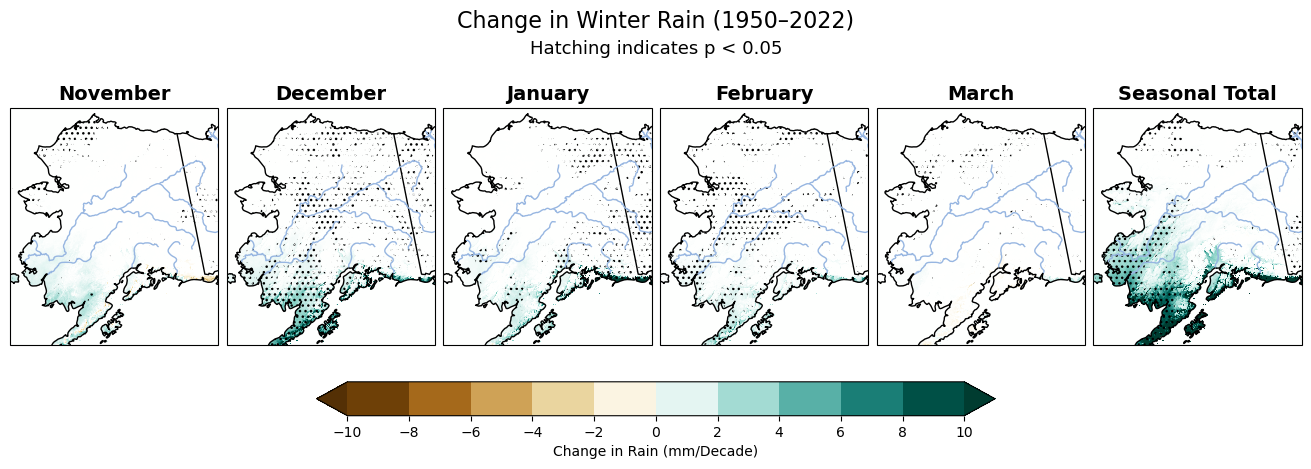

In [7]:
#rain_sum_slope_theilsen
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
vmin, vmax = -10,10
#vmin, vmax = -.5,.5
#cmap = 'BrBG'

levels = np.arange(-10, 12, 2)

cmap=brbg_white

datasets = [
    (monthly['rain_sum_slope_theilsen'].sel(month=11)*10,monthly['rain_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_sum_slope_theilsen'].sel(month=12)*10,monthly['rain_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_sum_slope_theilsen'].sel(month=1)*10,monthly['rain_sum_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['rain_sum_slope_theilsen'].sel(month=2)*10,monthly['rain_sum_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['rain_sum_slope_theilsen'].sel(month=3)*10,monthly['rain_sum_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['rain_sum_slope_theilsen']*10,seasonal['rain_sum_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) #anc
    ax.set_aspect('equal')

fig.suptitle("Change in Winter Rain (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in Rain (mm/Decade)')
cbar.set_ticks(levels)

fig.patch.set_alpha(0.0)
plt.show()

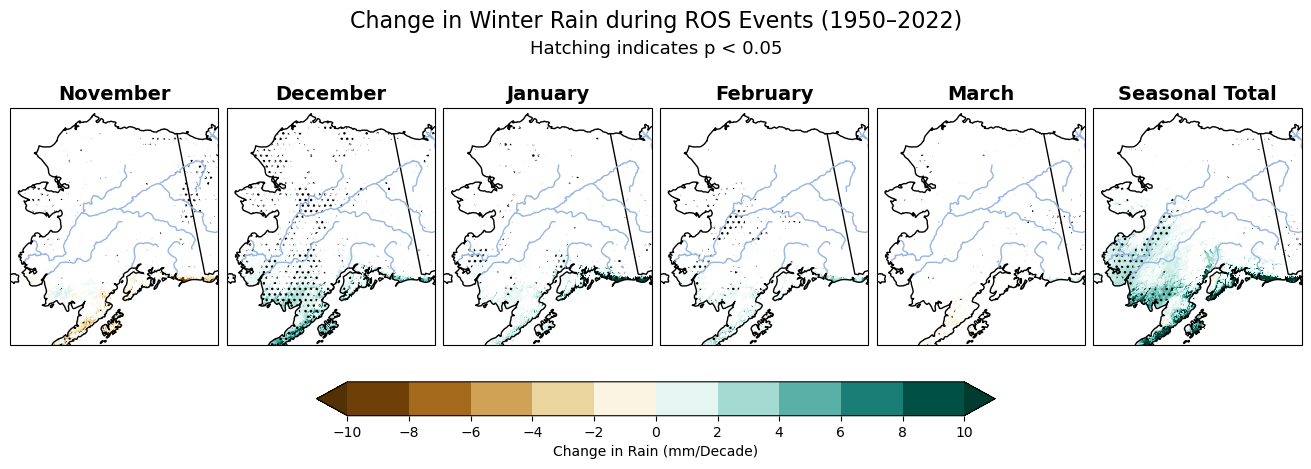

In [12]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10


from matplotlib.colors import LinearSegmentedColormap


#cmap = 'BrBG'
cmap=brbg_white

datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10,monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10,monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10,monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10,monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10,monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10,seasonal['rain_ros_sum_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Change in Winter Rain during ROS Events (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in Rain (mm/Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()

In [9]:
monthly

<xarray.Dataset> Size: 1GB
Dimensions:                                  (month: 5, south_north: 450,
                                              west_east: 420, interp_level: 3)
Coordinates:
  * month                                    (month) int64 40B 11 12 1 2 3
    XLAT                                     (south_north, west_east) float32 756kB ...
    XLONG                                    (south_north, west_east) float32 756kB ...
    month_name                               (month) <U3 60B ...
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/104)
    ros_tally_slope_theilsen                 (month, south_north, west_east) float64 8MB ...
    ros_tally_intercept_theilsen             (month, south_north, west_east) float64 8MB ...
    ros_tally_low_slope_theilsen             (month, south_north, west_east) float64 8MB ...
    ros_tally_high_slope_theilsen            (month, south_north, west_east) float64 8MB ...
    ros_counts_slope_theilsen                (month, south_north, west_east) float64 8MB ...
    ros_counts_intercept_theilsen            (month, south_north, west_east) float64 8MB ...
    ...                                       ...
    temp_levels_avg_S_mannkendall            (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_avg_var_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_tau_mannkendall      (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_p_value_mannkendall  (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_var_S_mannkendall    (month, interp_level, south_north, west_east) float64 23MB ...

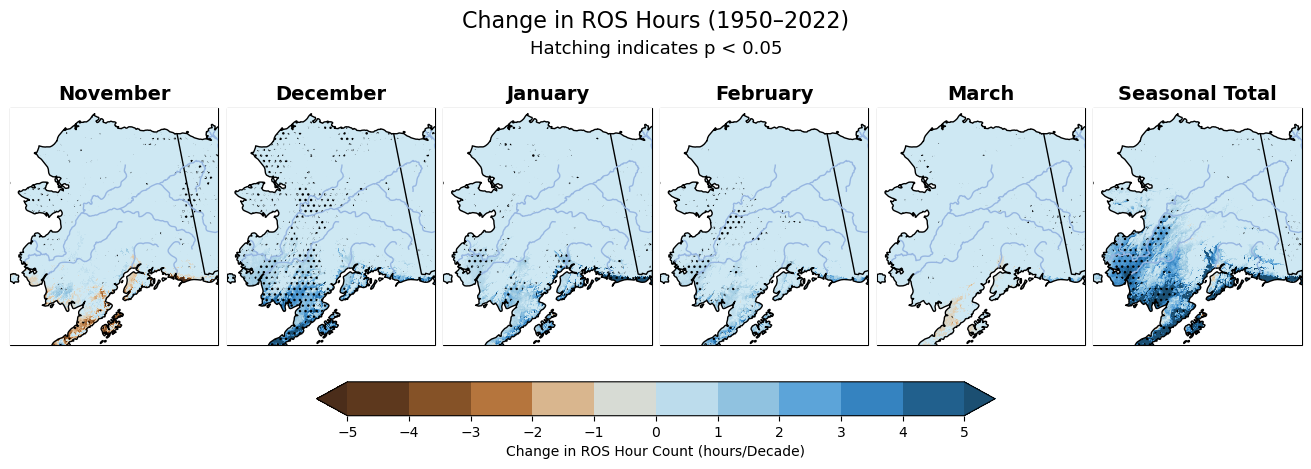

In [15]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
vmin, vmax = -5,5
#vmin, vmax = -.5,.5
#cmap = 'BrBG'

levels = np.arange(-5, 6, 1)

cmap=ros_colorbar

datasets = [
    (monthly['ros_tally_slope_theilsen'].sel(month=11)*10,monthly['ros_tally_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['ros_tally_slope_theilsen'].sel(month=12)*10,monthly['ros_tally_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['ros_tally_slope_theilsen'].sel(month=1)*10,monthly['ros_tally_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['ros_tally_slope_theilsen'].sel(month=2)*10,monthly['ros_tally_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['ros_tally_slope_theilsen'].sel(month=3)*10,monthly['ros_tally_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['ros_tally_slope_theilsen']*10,seasonal['ros_tally_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=3)
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) #anc
    ax.set_aspect('equal')

fig.suptitle("Change in ROS Hours (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in ROS Hour Count (hours/Decade)')
cbar.set_ticks(levels)

fig.patch.set_alpha(0.0)
plt.show()

NOW LOOKING AT  THE PERCENT 

In [10]:
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/'
compare=f'ROS_Monthly_*.nc'
file_list = sorted(glob.glob(os.path.join(path, compare)))
combined_ds=xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')
#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)

combined_ds = combined_ds.where(oceanmask != 17)

lat=combined_ds['XLAT']
lon=combined_ds['XLONG']
monthlist=['November','December','January','February','March' ]
monthnumberlist=[11,12,1,2,3]

Percent per decade found here 
-

In [11]:
nov_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=3),axis=0)
seasonal_ros_tally_avg=np.mean(combined_ds['ros_tally'].sum(axis=1),axis=0)

nov_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=11),axis=0)
dec_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=12),axis=0)
jan_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=1),axis=0)
feb_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=2),axis=0)
mar_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=3),axis=0)
seasonal_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sum(axis=1),axis=0)

nov_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=11),axis=0)
dec_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=12),axis=0)
jan_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=1),axis=0)
feb_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=2),axis=0)
mar_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=3),axis=0)
seasonal_rain_sum_avg=np.mean(combined_ds['rain_sum'].sum(axis=1),axis=0)

nov_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=11),axis=0)
dec_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=12),axis=0)
jan_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=1),axis=0)
feb_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=2),axis=0)
mar_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=3),axis=0)
seasonal_swe_avg=np.sum(combined_ds['swe_avg'],axis=1)
seasonal_swe_avg=np.mean(seasonal_swe_avg,axis=0)

nov_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=11),axis=0)
dec_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=12),axis=0)
jan_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=1),axis=0)
feb_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=2),axis=0)
mar_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=3),axis=0)
seasonal_t2_avg=np.mean(combined_ds['T2_avg'].sum(axis=1),axis=0)

nov_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=11),axis=0)
dec_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=12),axis=0)
jan_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=1),axis=0)
feb_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=2),axis=0)
mar_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=3),axis=0)
seasonal_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sum(axis=1),axis=0)


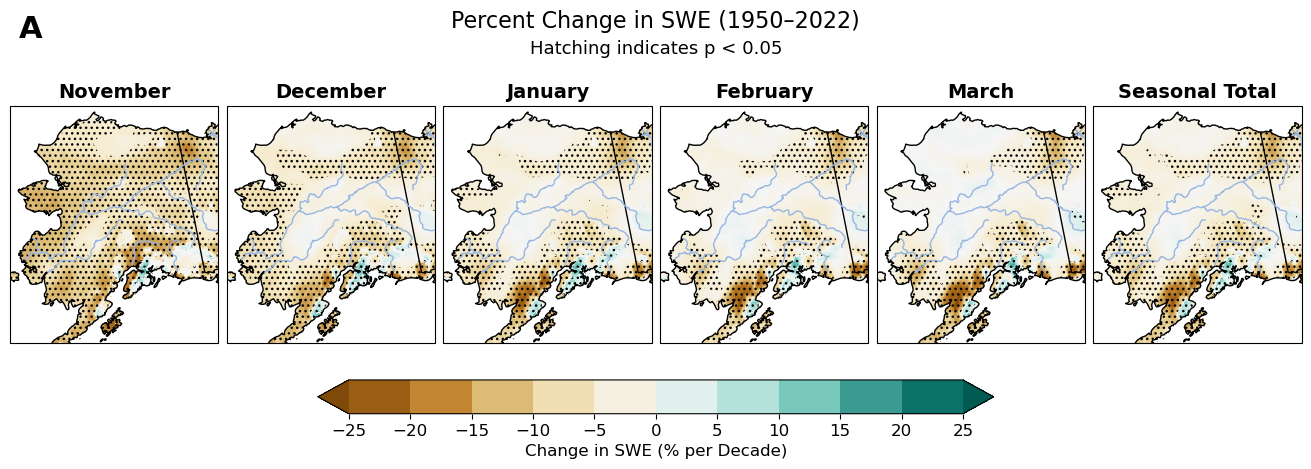

In [25]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)

vmin, vmax = -30,30


threshold=.1
datasets = [
    (monthly['swe_avg_slope_theilsen'].sel(month=11)*10/nov_swe_avg.where(nov_swe_avg > threshold)*100 ,monthly['swe_avg_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['swe_avg_slope_theilsen'].sel(month=12)*10/dec_swe_avg.where(dec_swe_avg > threshold) *100 ,monthly['swe_avg_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['swe_avg_slope_theilsen'].sel(month=1)*10/jan_swe_avg.where(jan_swe_avg> threshold) *100,monthly['swe_avg_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['swe_avg_slope_theilsen'].sel(month=2)*10/feb_swe_avg.where(feb_swe_avg>threshold) *100,monthly['swe_avg_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['swe_avg_slope_theilsen'].sel(month=3)*10/mar_swe_avg.where(mar_swe_avg>threshold)*100,monthly['swe_avg_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['swe_avg_slope_theilsen']*10/seasonal_swe_avg.where(seasonal_swe_avg>threshold) *100,seasonal['swe_avg_p_value_mannkendall'],"Seasonal Total")]


levels = np.arange(-25, 30, 5)



for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap='BrBG',
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree())
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree())  #anc
    #ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree()) #bethel
    ax.set_aspect('equal')

fig.suptitle("Percent Change in SWE (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels, orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label('Change in SWE (% per Decade)',size=12)
cbar.set_ticks(np.arange(-25,30, 5))
cbar.ax.tick_params(labelsize=12)
fig.text(0.01, 0.82, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
fig.patch.set_alpha(0.0)
plt.show()

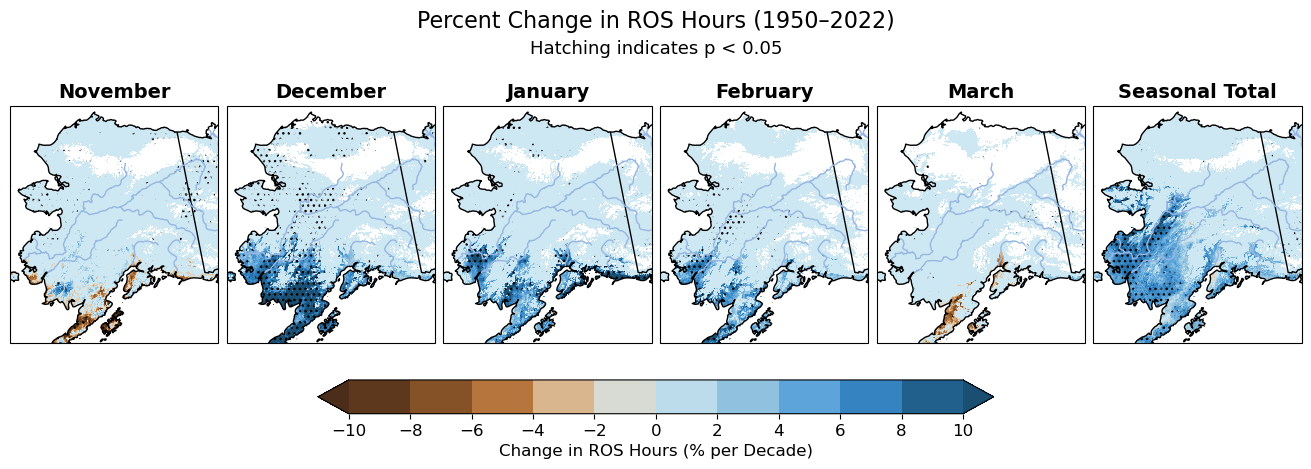

In [18]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10,12,2)
vmin, vmax = -10,10


cmap=ros_colorbar
#cmap = LinearSegmentedColormap.from_list('ros', ["brown", "tan", 'white', "lightblue", "darkblue"])
#cmap = 'coolwarm'
threshold=0.1
datasets = [
    (monthly['ros_tally_slope_theilsen'].sel(month=11)*10/nov_ros_tally_avg.where(nov_ros_tally_avg > threshold)*100 ,monthly['ros_tally_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['ros_tally_slope_theilsen'].sel(month=12)*10/dec_ros_tally_avg.where(dec_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['ros_tally_slope_theilsen'].sel(month=1)*10/jan_ros_tally_avg.where(jan_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['ros_tally_slope_theilsen'].sel(month=2)*10/feb_ros_tally_avg.where(feb_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['ros_tally_slope_theilsen'].sel(month=3)*10/mar_ros_tally_avg.where(mar_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['ros_tally_slope_theilsen']*10/seasonal_ros_tally_avg.where(seasonal_ros_tally_avg > threshold)*100,seasonal['ros_tally_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap= ros_colorbar,
        #cmap='BrBG',
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree())
    
    
    #ax.set_title(title)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')


fig.suptitle("Percent Change in ROS Hours (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels, orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in ROS Hours (% per Decade)',size=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=12)
fig.patch.set_alpha(0.0)
plt.show()

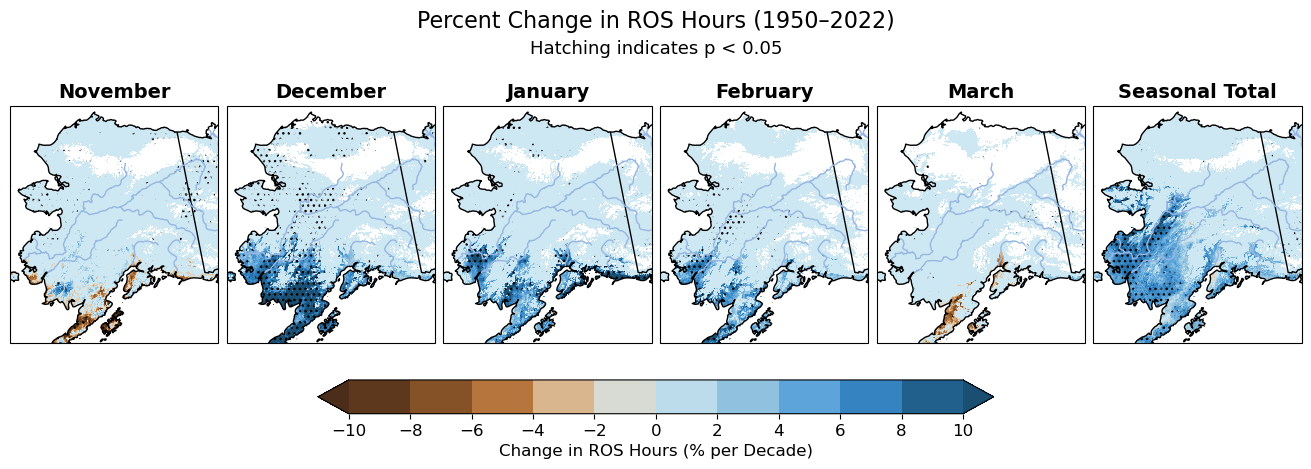

In [19]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10,12,2)
vmin, vmax = -10,10


cmap=ros_colorbar
#cmap = LinearSegmentedColormap.from_list('ros', ["brown", "tan", 'white', "lightblue", "darkblue"])
#cmap = 'coolwarm'
threshold=0.1
datasets = [
    (monthly['ros_tally_slope_theilsen'].sel(month=11)*10/nov_ros_tally_avg.where(nov_ros_tally_avg > threshold)*100 ,monthly['ros_tally_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['ros_tally_slope_theilsen'].sel(month=12)*10/dec_ros_tally_avg.where(dec_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['ros_tally_slope_theilsen'].sel(month=1)*10/jan_ros_tally_avg.where(jan_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['ros_tally_slope_theilsen'].sel(month=2)*10/feb_ros_tally_avg.where(feb_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['ros_tally_slope_theilsen'].sel(month=3)*10/mar_ros_tally_avg.where(mar_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['ros_tally_slope_theilsen']*10/seasonal_ros_tally_avg.where(seasonal_ros_tally_avg > threshold)*100,seasonal['ros_tally_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap= ros_colorbar,
        #cmap='BrBG',
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree())
    
    
    #ax.set_title(title)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree()) #all
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree())  #anc
    #ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree()) #bethel
    ax.set_aspect('equal')


fig.suptitle("Percent Change in ROS Hours (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels, orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in ROS Hours (% per Decade)',size=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=12)
fig.patch.set_alpha(0.0)
plt.show()

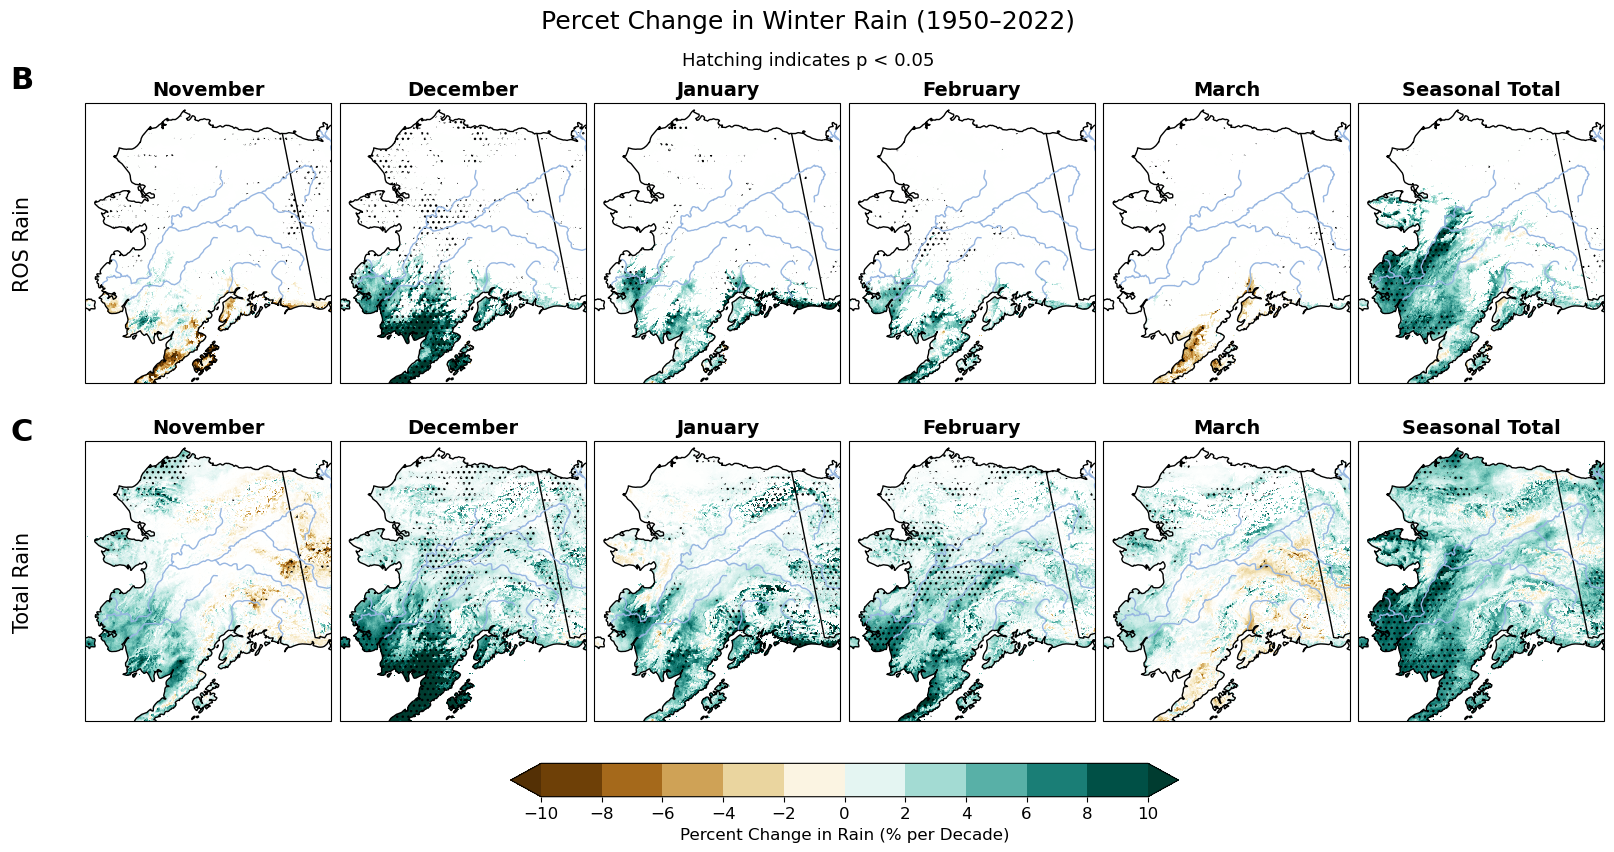

In [30]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(
    nrows=2, ncols=6,
    figsize=(16, 8),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10, 10
cmap = rain_colorbar

threshold_rain=0.1
#threshold=0.1
ros_datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold_rain)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold_rain)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold_rain)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold_rain)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold_rain)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold_rain)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]


rain_datasets = [
    (monthly['rain_sum_slope_theilsen'].sel(month=11)*10/nov_rain_sum_avg.where(nov_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_sum_slope_theilsen'].sel(month=12)*10/dec_rain_sum_avg.where(dec_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_sum_slope_theilsen'].sel(month=1)*10/jan_rain_sum_avg.where(jan_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_sum_slope_theilsen'].sel(month=2)*10/feb_rain_sum_avg.where(feb_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_sum_slope_theilsen'].sel(month=3)*10/mar_rain_sum_avg.where(mar_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_sum_slope_theilsen']*10/seasonal_rain_sum_avg.where(seasonal_rain_sum_avg > threshold_rain)*100, seasonal['rain_sum_p_value_mannkendall'], "Seasonal Total")
]

pcm = plot_row(axs[0], ros_datasets)
plot_row(axs[1], rain_datasets)

axs[0,0].text(-0.25, 0.5, "ROS Rain",
              rotation=90, transform=axs[0,0].transAxes,
              va='center', ha='center', fontsize=15)

axs[1,0].text(-0.25, 0.5, "Total Rain",
              rotation=90, transform=axs[1,0].transAxes,
              va='center', ha='center', fontsize=15)

fig.suptitle("Percet Change in Winter Rain (1950–2022)\n", fontsize=18, y=1.05)
fig.text(0.5, 0.98, "Hatching indicates p < 0.05",
         ha='center', fontsize=13)

cbar = fig.colorbar(
    pcm, ax=axs,
    orientation='horizontal',
    fraction=0.05, pad=0.06,
    extend='both',
    boundaries=levels
)
cbar.set_label('Percent Change in Rain (% per Decade)',size=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=12)
fig.text(0.001, 0.98, 'B', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.001, 0.54, 'C', fontsize=22, fontweight='bold', va='top', ha='left')
fig.patch.set_alpha(0.0)
plt.show()


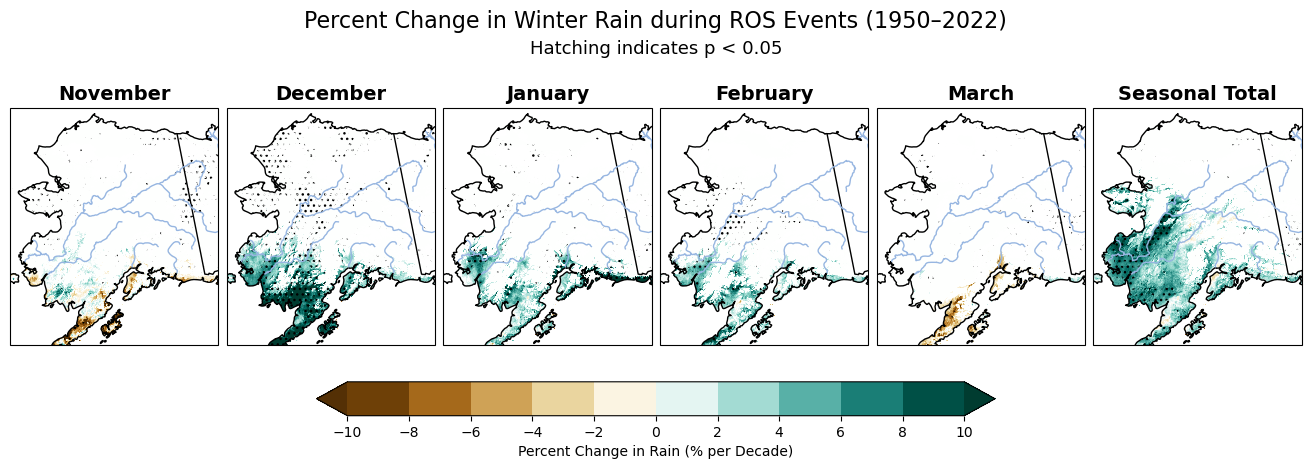

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = rain_colorbar

threshold=0.1 

datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree()) #all
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree())  #anc
    #ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree()) #bethel
    ax.set_aspect('equal')

fig.suptitle("Percent Change in Winter Rain during ROS Events (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in Rain (% per Decade)')
cbar.set_ticks(levels)

fig.patch.set_alpha(0.0)
plt.show()

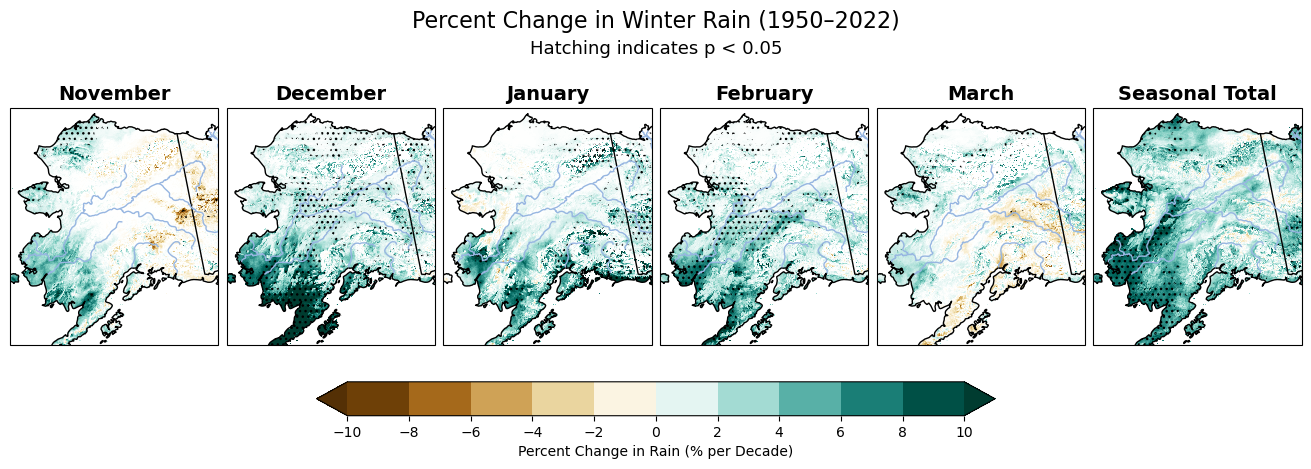

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = rain_colorbar
threshold_rain=0.1

datasets = [
    (monthly['rain_sum_slope_theilsen'].sel(month=11)*10/nov_rain_sum_avg.where(nov_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_sum_slope_theilsen'].sel(month=12)*10/dec_rain_sum_avg.where(dec_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_sum_slope_theilsen'].sel(month=1)*10/jan_rain_sum_avg.where(jan_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_sum_slope_theilsen'].sel(month=2)*10/feb_rain_sum_avg.where(feb_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_sum_slope_theilsen'].sel(month=3)*10/mar_rain_sum_avg.where(mar_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_sum_slope_theilsen']*10/seasonal_rain_sum_avg.where(seasonal_rain_sum_avg > threshold_rain)*100, seasonal['rain_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree()) #all
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree())  #anc
    #ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree()) #bethel
    ax.set_aspect('equal')

fig.suptitle("Percent Change in Winter Rain (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in Rain (% per Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()

In [ ]:
nov_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=11),axis=0)
dec_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=12),axis=0)
jan_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=1),axis=0)
feb_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=2),axis=0)
mar_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=3),axis=0)
seasonal_t2_avg=np.mean(combined_ds['T2_avg'].sum(axis=1),axis=0)

nov_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=11),axis=0)
dec_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=12),axis=0)
jan_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=1),axis=0)
feb_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=2),axis=0)
mar_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=3),axis=0)
seasonal_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sum(axis=1),axis=0)

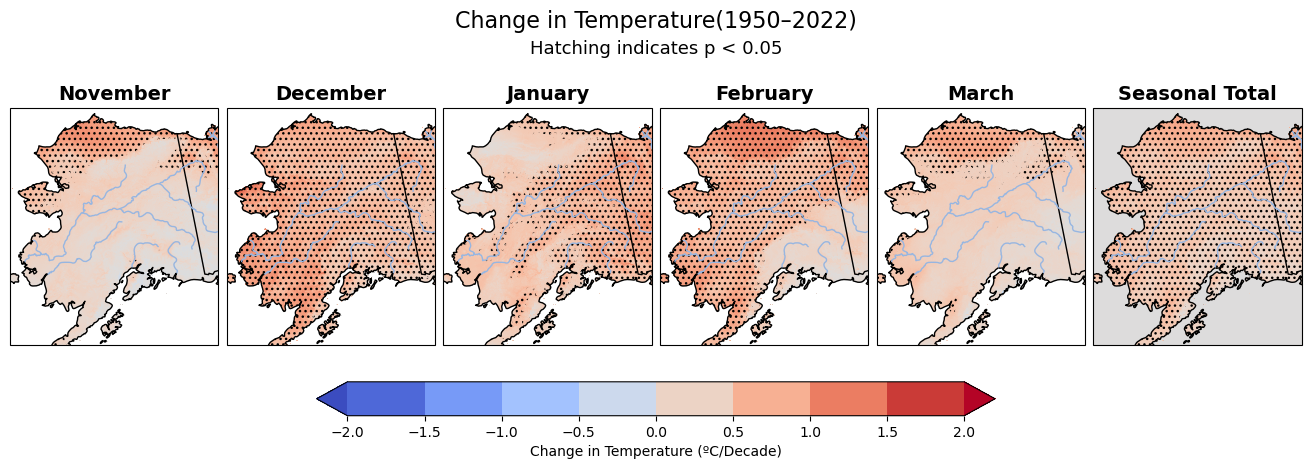

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-2, 2.5, .5)
vmin, vmax = -2,2
cmap = 'coolwarm'

datasets = [
    (monthly['T2_avg_slope_theilsen'].sel(month=11)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['T2_avg_slope_theilsen'].sel(month=12)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['T2_avg_slope_theilsen'].sel(month=1)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['T2_avg_slope_theilsen'].sel(month=2)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['T2_avg_slope_theilsen'].sel(month=3)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=3), "March"),
    ((seasonal['T2_avg_slope_theilsen']/5)*10,seasonal['T2_avg_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Change in Temperature(1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in Temperature (ºC/Decade)')
cbar.set_ticks(np.arange(-2, 2.5, .5))

fig.patch.set_alpha(0.0)
plt.show()


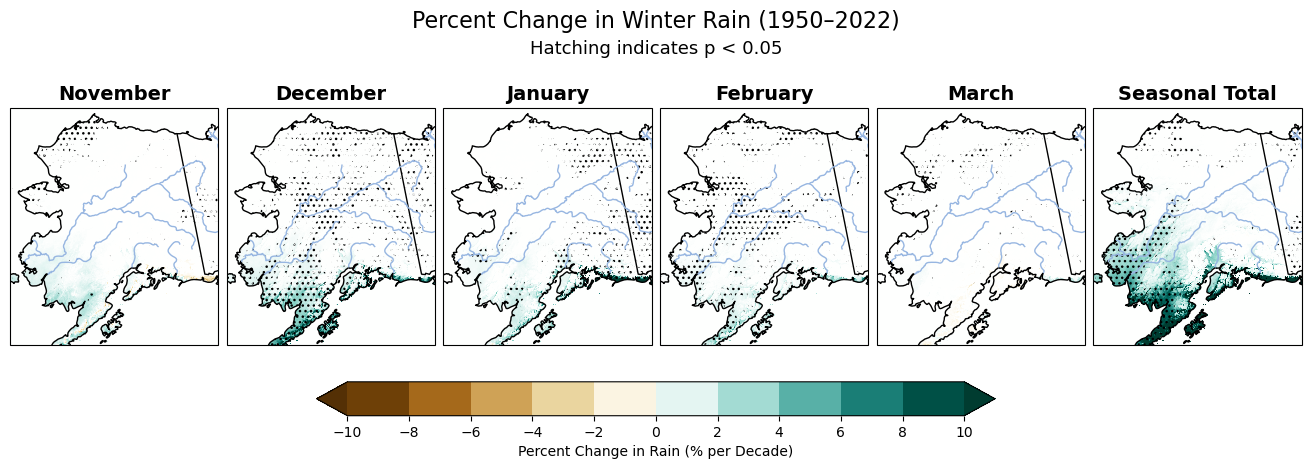

In [21]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = rain_colorbar
threshold_rain=0.1

datasets = [
    (monthly['rain_sum_slope_theilsen'].sel(month=11)*10, monthly['rain_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_sum_slope_theilsen'].sel(month=12)*10, monthly['rain_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_sum_slope_theilsen'].sel(month=1)*10,  monthly['rain_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_sum_slope_theilsen'].sel(month=2)*10,  monthly['rain_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_sum_slope_theilsen'].sel(month=3)*10,  monthly['rain_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_sum_slope_theilsen']*10, seasonal['rain_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree()) #all
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree())  #anc
    #ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree()) #bethel
    ax.set_aspect('equal')

fig.suptitle("Percent Change in Winter Rain (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Hatching indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in Rain (% per Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()